In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel("BD/06_MATRICULAS_ED_SUPERIOR_VALPARAISO_2021.xlsx")
df

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,10,Femenino,24,20 a 24,2016,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Salud,10,0,10,130000,3713000,Valparaiso,Valparaiso,Vina Del Mar
1,25,Femenino,19,15 a 19,2021,Primer semestre,Institutos Profesionales,IP INSTITUTO DE ESTUDIOS BANCARIOS GUILLERMO S...,ACREDITADA,17/12/2017 AL 17/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,190000,1900000,Valparaiso,Valparaiso,Vina Del Mar
2,28,Masculino,24,20 a 24,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Profesionales,Administracion y Comercio,8,1,8,190000,1760000,Valparaiso,San Felipe De Aconcagua,San Felipe
3,29,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,PONTIFICIA UNIVERSIDAD CATOLICA DE VALPARAISO,ACREDITADA,26/11/2015 AL 26/11/2021,...,Carreras Profesionales,Educacion,9,0,9,208000,2558000,Valparaiso,Valparaiso,Valparaiso
4,42,Masculino,26,25 a 29,2014,Primer semestre,Universidades CRUCH,UNIVERSIDAD TECNICA FEDERICO SANTA MARIA,ACREDITADA,29/12/2016 AL 29/12/2022,...,Carreras Profesionales,Arte y Arquitectura,10,1,11,186000,4350000,Valparaiso,Valparaiso,Valparaiso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109193,1048489,Masculino,40,40 y mas,2015,Segundo semestre,Universidades Privadas,UNIVERSIDAD DE LAS AMERICAS,ACREDITADA,17/03/2019 AL 17/03/2023,...,Carreras Profesionales,Ciencias Sociales,11,0,11,170000,4000000,Valparaiso,Valparaiso,Vina Del Mar
109194,1048493,Masculino,23,20 a 24,2021,Primer semestre,Institutos Profesionales,IP DUOC UC,ACREDITADA,26/08/2017 AL 26/08/2024,...,Carreras Tecnicas,Ciencias Basicas,5,1,5,176000,2060000,Valparaiso,Valparaiso,Valparaiso
109195,1048494,Masculino,23,20 a 24,2017,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE PLAYA ANCHA DE CIENCIAS DE LA E...,ACREDITADA,27/09/2016 AL 27/09/2021,...,Carreras Profesionales,Educacion,9,1,9,152000,2465000,Valparaiso,Valparaiso,Valparaiso
109196,1048503,Masculino,35,35 a 39,2020,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Tecnicas,Administracion y Comercio,5,1,5,190000,1880000,Valparaiso,San Antonio,San Antonio


# Pregunta 4: Correlación entre Matrícula y Arancel

Estudiaremos la correlación entre el valor de la matrícula y el valor del arancel para toda la base de datos y luego separaremos por tipo de institución.

**Preguntas a responder:**
- ¿Los grupos se comportan parecido?
- ¿Vale la pena estudiar todos los grupos?

In [ ]:
# Limpiar datos: eliminar valores nulos y valores de arancel = 0
df_limpio = df[['TIPO DE INSTITUCION', 'VALOR MATRICULA (PESOS)', 'VALOR ARANCEL (PESOS)']].copy()
df_limpio = df_limpio.dropna()
df_limpio = df_limpio[df_limpio['VALOR ARANCEL (PESOS)'] > 0]

print(f"Registros originales: {len(df)}")
print(f"Registros después de limpieza: {len(df_limpio)}")
print(f"\nTipos de institución:\n{df_limpio['TIPO DE INSTITUCION'].value_counts()}")

## 1. Correlación Global (Toda la Base de Datos)

In [3]:
# Calcular correlación global
corr_global = df['VALOR MATRICULA (PESOS)'].corr(df['VALOR ARANCEL (PESOS)'])

print(f"Correlación global entre Matrícula y Arancel: {corr_global:.4f}")
print(f"\nInterpretación:")
if corr_global > 0.7:
    print("  - Correlación fuerte positiva")
elif corr_global > 0.4:
    print("  - Correlación moderada positiva")
elif corr_global > 0:
    print("  - Correlación débil positiva")
else:
    print("  - Correlación negativa o nula")

Correlación global entre Matrícula y Arancel: 0.5657

Interpretación:
  - Correlación moderada positiva


## 2. Correlación por Tipo de Institución

In [4]:
# Calcular correlación por tipo de institución
correlaciones = df.groupby('TIPO DE INSTITUCION').apply(
    lambda x: x['VALOR MATRICULA (PESOS)'].corr(x['VALOR ARANCEL (PESOS)'])
).sort_values(ascending=False)

print("Correlación por Tipo de Institución:")
print("="*50)
for institucion, corr in correlaciones.items():
    print(f"{institucion:35s}: {corr:.4f}")

# Crear tabla resumida con estadísticas por grupo
print("\n" + "="*50)
print("Estadísticas por Tipo de Institución:")
print("="*50)

estadisticas = df.groupby('TIPO DE INSTITUCION').agg({
    'VALOR MATRICULA (PESOS)': ['mean', 'std'],
    'VALOR ARANCEL (PESOS)': ['mean', 'std']
}).round(0)

estadisticas.columns = ['Mat_Media', 'Mat_Std', 'Ara_Media', 'Ara_Std']
estadisticas['Correlacion'] = correlaciones
estadisticas['N'] = df.groupby('TIPO DE INSTITUCION').size()

print(estadisticas)

Correlación por Tipo de Institución:
Institutos Profesionales           : 0.7087
Universidades Privadas             : 0.6313
Centros de Formacion Tecnica       : 0.5540
Universidades CRUCH                : 0.4517

Estadísticas por Tipo de Institución:
                              Mat_Media   Mat_Std  Ara_Media    Ara_Std  \
TIPO DE INSTITUCION                                                       
Centros de Formacion Tecnica   137918.0   70013.0  1656787.0   362243.0   
Institutos Profesionales       194967.0   46350.0  2137891.0   411533.0   
Universidades CRUCH            183980.0   30570.0  3586519.0   995947.0   
Universidades Privadas         337154.0  169103.0  4082777.0  1264818.0   

                              Correlacion      N  
TIPO DE INSTITUCION                               
Centros de Formacion Tecnica     0.554010  10839  
Institutos Profesionales         0.708667  28172  
Universidades CRUCH              0.451659  43702  
Universidades Privadas           0.631326 

/var/folders/_d/bcbtk5vn291fk9tnt4fkrlj80000gn/T/ipykernel_48643/2658075550.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlaciones = df.groupby('TIPO DE INSTITUCION').apply(


## 3. Visualización: Scatter Plot Global

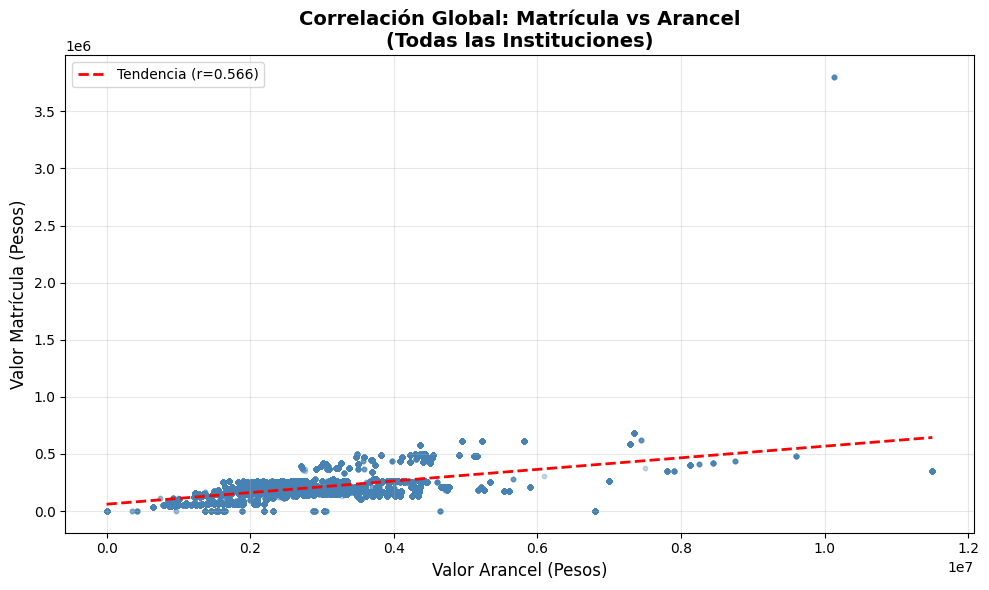

In [5]:
# Scatter plot global con línea de regresión
plt.figure(figsize=(10, 6))
plt.scatter(df['VALOR ARANCEL (PESOS)'], 
            df['VALOR MATRICULA (PESOS)'],
            alpha=0.3, s=10, color='steelblue')

# Agregar línea de tendencia
z = np.polyfit(df['VALOR ARANCEL (PESOS)'], df['VALOR MATRICULA (PESOS)'], 1)
p = np.poly1d(z)
plt.plot(df['VALOR ARANCEL (PESOS)'].sort_values(), 
         p(df['VALOR ARANCEL (PESOS)'].sort_values()), 
         "r--", linewidth=2, label=f'Tendencia (r={corr_global:.3f})')

plt.xlabel('Valor Arancel (Pesos)', fontsize=12)
plt.ylabel('Valor Matrícula (Pesos)', fontsize=12)
plt.title('Correlación Global: Matrícula vs Arancel\n(Todas las Instituciones)', 
          fontsize=14, weight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Visualización: Scatter Plot por Tipo de Institución

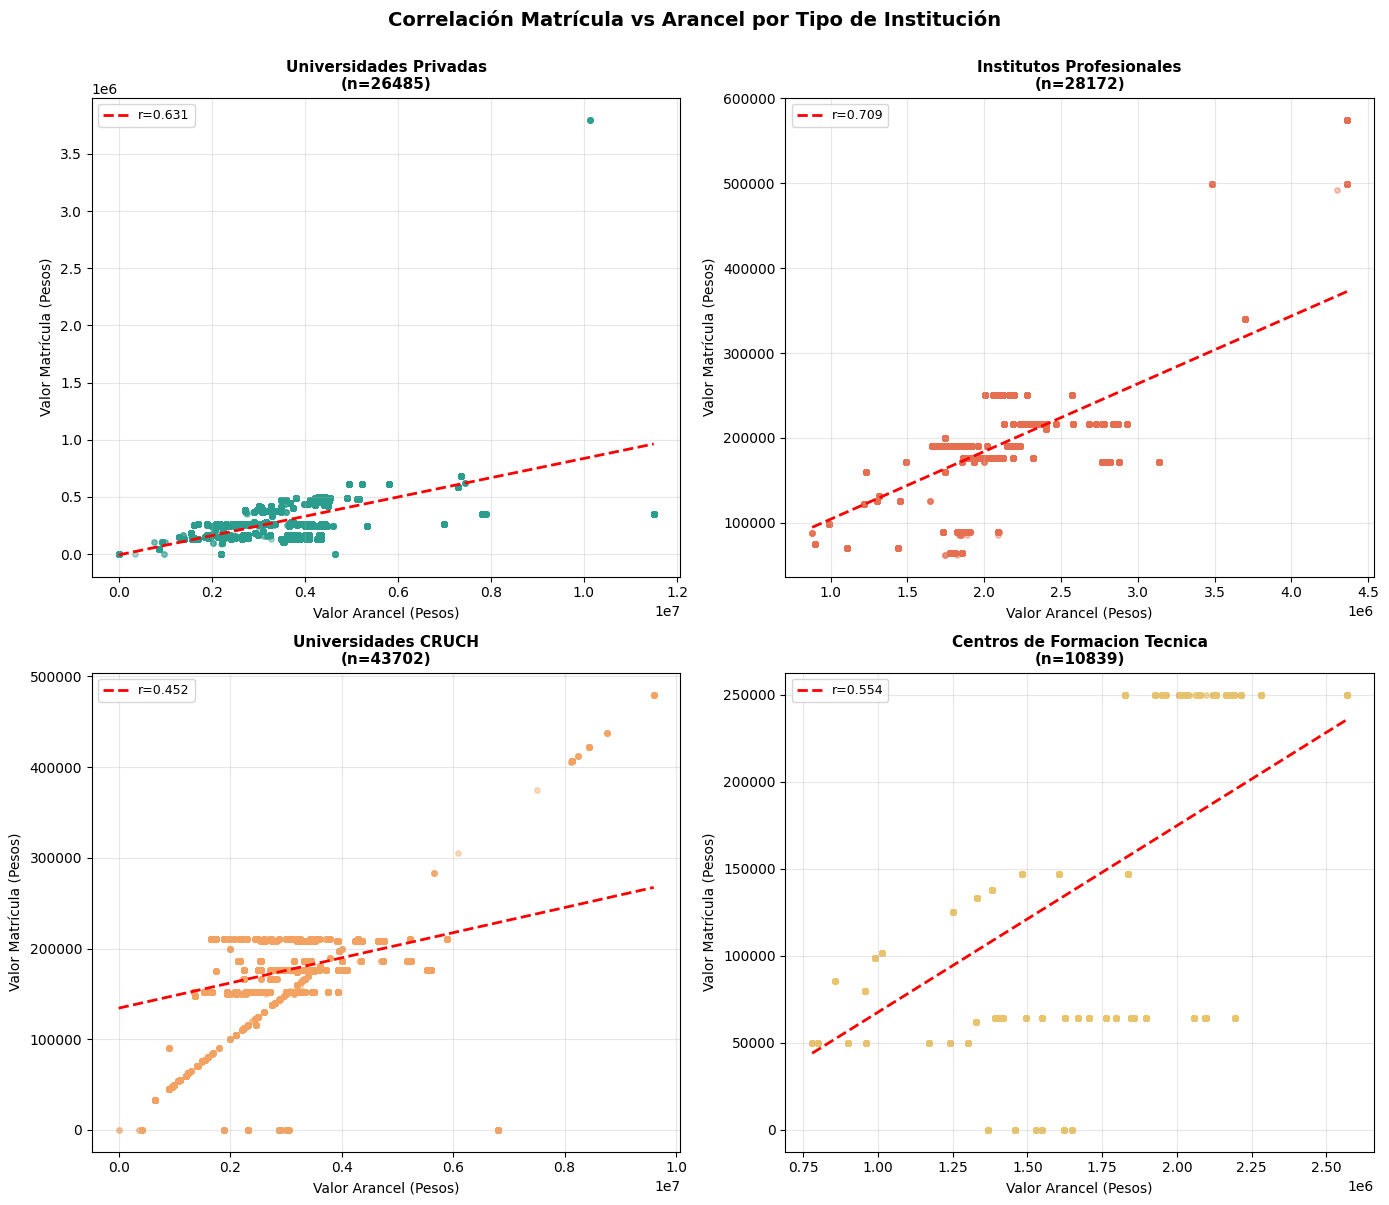

In [6]:
# Scatter plot separado por tipo de institución (2x2 subplots)
tipos = df['TIPO DE INSTITUCION'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colores = ['#2a9d8f', '#e76f51', '#f4a261', '#e9c46a']

for idx, (tipo, color) in enumerate(zip(tipos, colores)):
    df_tipo = df[df['TIPO DE INSTITUCION'] == tipo]
    corr_tipo = correlaciones[tipo]
    
    axes[idx].scatter(df_tipo['VALOR ARANCEL (PESOS)'], 
                      df_tipo['VALOR MATRICULA (PESOS)'],
                      alpha=0.4, s=15, color=color)
    
    # Línea de tendencia
    if len(df_tipo) > 1:
        z = np.polyfit(df_tipo['VALOR ARANCEL (PESOS)'], df_tipo['VALOR MATRICULA (PESOS)'], 1)
        p = np.poly1d(z)
        axes[idx].plot(df_tipo['VALOR ARANCEL (PESOS)'].sort_values(), 
                       p(df_tipo['VALOR ARANCEL (PESOS)'].sort_values()), 
                       "r--", linewidth=2, label=f'r={corr_tipo:.3f}')
    
    axes[idx].set_xlabel('Valor Arancel (Pesos)', fontsize=10)
    axes[idx].set_ylabel('Valor Matrícula (Pesos)', fontsize=10)
    axes[idx].set_title(f'{tipo}\n(n={len(df_tipo)})', fontsize=11, weight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Correlación Matrícula vs Arancel por Tipo de Institución', 
             fontsize=14, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 5. Visualización Comparativa: Todas las Instituciones en un Solo Gráfico

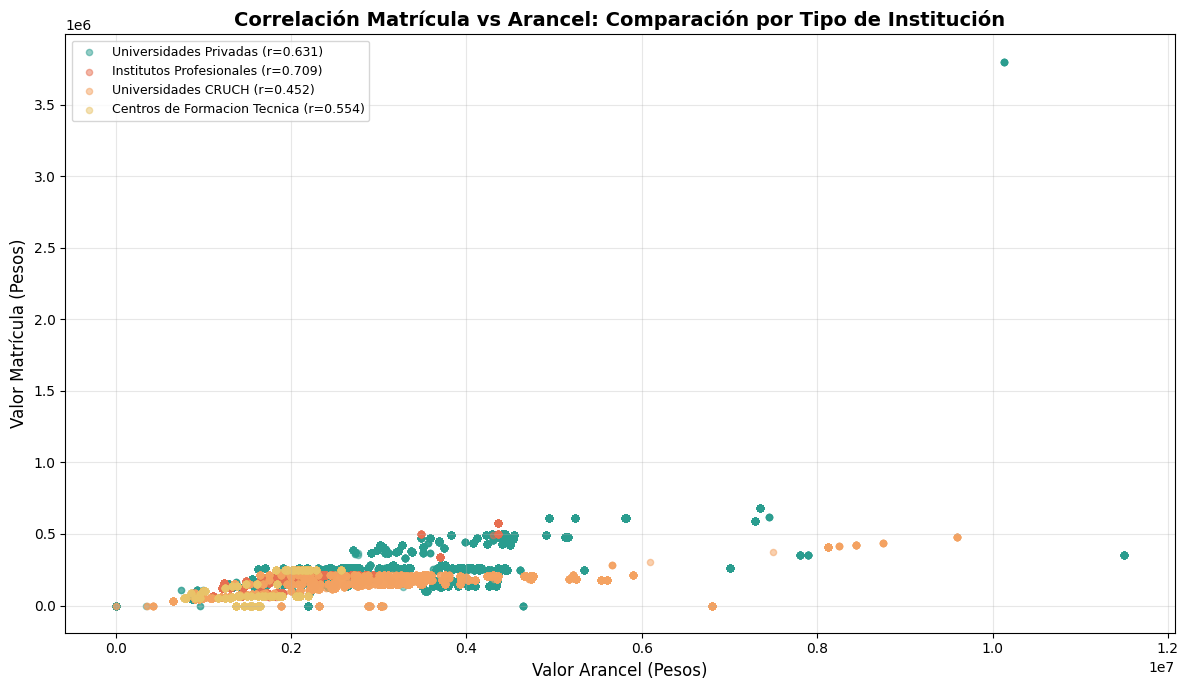

In [7]:
# Scatter plot con colores por tipo de institución
plt.figure(figsize=(12, 7))

for idx, (tipo, color) in enumerate(zip(tipos, colores)):
    df_tipo = df[df['TIPO DE INSTITUCION'] == tipo]
    corr_tipo = correlaciones[tipo]
    plt.scatter(df_tipo['VALOR ARANCEL (PESOS)'], 
                df_tipo['VALOR MATRICULA (PESOS)'],
                alpha=0.5, s=20, color=color, 
                label=f'{tipo} (r={corr_tipo:.3f})')

plt.xlabel('Valor Arancel (Pesos)', fontsize=12)
plt.ylabel('Valor Matrícula (Pesos)', fontsize=12)
plt.title('Correlación Matrícula vs Arancel: Comparación por Tipo de Institución', 
          fontsize=14, weight='bold')
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Gráfico de Barras: Comparación de Correlaciones

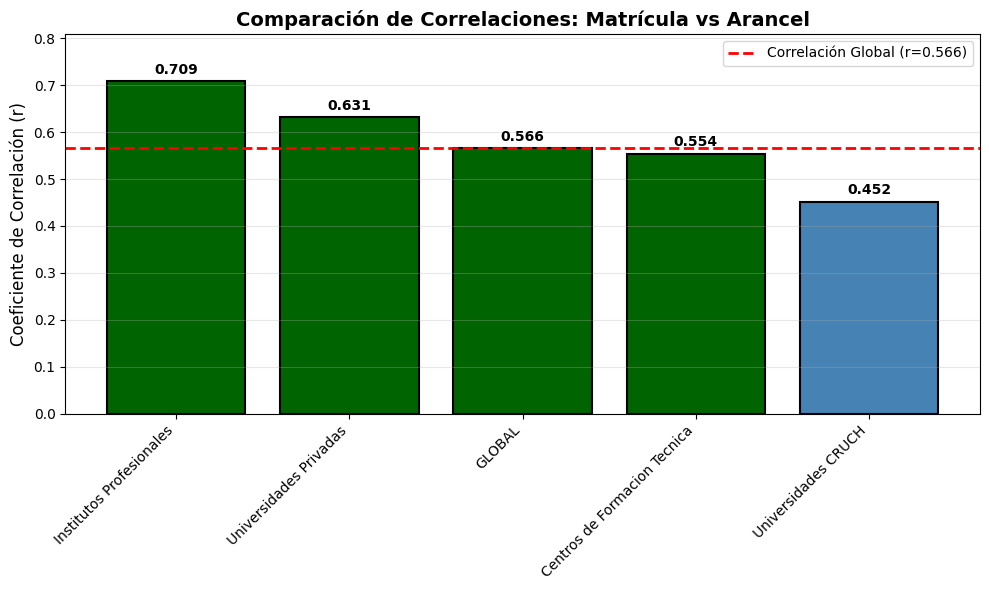

In [8]:
# Gráfico de barras comparando correlaciones
plt.figure(figsize=(10, 6))

# Agregar la correlación global
correlaciones_completo = correlaciones.copy()
correlaciones_completo['GLOBAL'] = corr_global
correlaciones_completo = correlaciones_completo.sort_values(ascending=False)

colores_barras = ['darkgreen' if idx < len(tipos) else 'steelblue' 
                  for idx in range(len(correlaciones_completo))]

bars = plt.bar(range(len(correlaciones_completo)), 
               correlaciones_completo.values, 
               color=colores_barras, 
               edgecolor='black', 
               linewidth=1.5)

plt.xticks(range(len(correlaciones_completo)), 
           correlaciones_completo.index, 
           rotation=45, 
           ha='right')

# Agregar valores sobre las barras
for i, (bar, value) in enumerate(zip(bars, correlaciones_completo.values)):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.01, 
             f'{value:.3f}', 
             ha='center', va='bottom', fontsize=10, weight='bold')

plt.ylabel('Coeficiente de Correlación (r)', fontsize=12)
plt.title('Comparación de Correlaciones: Matrícula vs Arancel', 
          fontsize=14, weight='bold')
plt.ylim(0, max(correlaciones_completo.values) + 0.1)
plt.axhline(y=corr_global, color='red', linestyle='--', 
            linewidth=2, label=f'Correlación Global (r={corr_global:.3f})')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Análisis y Conclusiones

In [10]:
# Análisis de diferencias entre grupos
print("ANÁLISIS DE COMPORTAMIENTO POR GRUPOS")
print("="*70)
print(f"\n1. Correlación Global: {corr_global:.4f}")
print(f"\n2. Rango de correlaciones por tipo: [{correlaciones.min():.4f}, {correlaciones.max():.4f}]")
print(f"\n3. Diferencia máxima entre grupos: {correlaciones.max() - correlaciones.min():.4f}")
print(f"\n4. Desviación estándar de correlaciones: {correlaciones.std():.4f}")

# Determinar si los grupos se comportan parecido
diferencia_max = correlaciones.max() - correlaciones.min()
std_corr = correlaciones.std()

print("\n" + "="*70)
print("RESPUESTA A LAS PREGUNTAS:")
print("="*70)

print("\n¿Los grupos se comportan parecido?")
if diferencia_max < 0.2 and std_corr < 0.1:
    print("  → SÍ, los grupos se comportan de manera muy similar.")
    print(f"    La diferencia máxima es {diferencia_max:.4f} (< 0.2)")
elif diferencia_max < 0.4 and std_corr < 0.15:
    print("  → PARCIALMENTE, hay algunas diferencias moderadas entre grupos.")
    print(f"    La diferencia máxima es {diferencia_max:.4f}")
else:
    print("  → NO, los grupos muestran comportamientos bastante diferentes.")
    print(f"    La diferencia máxima es {diferencia_max:.4f} (≥ 0.4)")

print("\n¿Vale la pena estudiar todos los grupos?")
if diferencia_max > 0.3 or any(abs(correlaciones - corr_global) > 0.2):
    print("  → SÍ, vale la pena estudiar cada grupo por separado porque:")
    print("    - Existen diferencias significativas entre grupos")
    print("    - Algunos grupos se desvían considerablemente del comportamiento global")
    print("    - El análisis agregado puede ocultar patrones específicos")
else:
    print("  → NO necesariamente, el análisis global es representativo porque:")
    print("    - Las diferencias entre grupos son pequeñas")
    print("    - Todos los grupos se comportan de manera similar al promedio global")

print("\n" + "="*70)
print("OBSERVACIONES ESPECÍFICAS:")
print("="*70)

for tipo in correlaciones.index:
    corr = correlaciones[tipo]
    diff = abs(corr - corr_global)
    n = len(df[df['TIPO DE INSTITUCION'] == tipo])
    print(f"\n{tipo}:")
    print(f"  - Correlación: {corr:.4f}")
    print(f"  - Diferencia con global: {diff:.4f}")
    print(f"  - Tamaño de muestra: {n} registros")
    if diff > 0.2:
        print(f"  - ⚠️ COMPORTAMIENTO DIFERENTE al promedio global")
    else:
        print(f"  - ✓ Comportamiento similar al promedio global")

ANÁLISIS DE COMPORTAMIENTO POR GRUPOS

1. Correlación Global: 0.5657

2. Rango de correlaciones por tipo: [0.4517, 0.7087]

3. Diferencia máxima entre grupos: 0.2570

4. Desviación estándar de correlaciones: 0.1098

RESPUESTA A LAS PREGUNTAS:

¿Los grupos se comportan parecido?
  → PARCIALMENTE, hay algunas diferencias moderadas entre grupos.
    La diferencia máxima es 0.2570

¿Vale la pena estudiar todos los grupos?
  → NO necesariamente, el análisis global es representativo porque:
    - Las diferencias entre grupos son pequeñas
    - Todos los grupos se comportan de manera similar al promedio global

OBSERVACIONES ESPECÍFICAS:

Institutos Profesionales:
  - Correlación: 0.7087
  - Diferencia con global: 0.1430
  - Tamaño de muestra: 28172 registros
  - ✓ Comportamiento similar al promedio global

Universidades Privadas:
  - Correlación: 0.6313
  - Diferencia con global: 0.0656
  - Tamaño de muestra: 26485 registros
  - ✓ Comportamiento similar al promedio global

Centros de Formaci

## Conclusiones Finales

### Hallazgos Principales:

1. **Correlación Global (r = 0.5657)**:
   - Existe una correlación **moderada positiva** entre el valor de la matrícula y el arancel en toda la base de datos.
   - Esto significa que, en general, cuando aumenta el arancel, tiende a aumentar también el valor de la matrícula, aunque la relación no es perfecta.
   - Esta correlación es lo suficientemente fuerte como para ser relevante, pero deja espacio para otros factores que también influyen en el precio de la matrícula.

2. **Diferencias por Tipo de Institución**:

   Las correlaciones varían considerablemente según el tipo de institución:
   
   - **Institutos Profesionales (r = 0.7087)**: Correlación **fuerte positiva**
     - Es el grupo con mayor correlación matrícula-arancel
     - En los IP existe una relación más predecible y lineal entre ambas variables
     - Posiblemente porque tienen políticas de precios más estandarizadas
   
   - **Universidades Privadas (r = 0.6313)**: Correlación **moderada-fuerte**
     - Segunda correlación más alta
     - Muestran mayor variabilidad en precios (Mat_Media: $337,154 con Std: $169,103)
     - Esta alta desviación estándar sugiere estrategias de pricing muy diversas
   
   - **Centros de Formación Técnica (r = 0.5540)**: Correlación **moderada**
     - Muy cercana al promedio global
     - Representan el comportamiento más típico de la muestra
     - Valores de matrícula y arancel más accesibles y homogéneos
   
   - **Universidades CRUCH (r = 0.4517)**: Correlación **moderada-débil**
     - Es el grupo con **menor correlación**
     - Esto sugiere que en las universidades del CRUCH el valor de la matrícula está menos determinado por el arancel
     - Posiblemente debido a políticas de gratuidad, becas institucionales, o criterios más complejos de fijación de precios
     - A pesar de tener aranceles altos (Ara_Media: $3,586,519), mantienen matrículas relativamente bajas y homogéneas (Mat_Media: $183,980, Std: $30,570)

3. **¿Los grupos se comportan parecido?**

   **RESPUESTA: PARCIALMENTE**
   
   - La diferencia máxima entre correlaciones es de **0.2570** (entre IP y CRUCH)
   - La desviación estándar de las correlaciones es **0.1098**
   - Aunque todos los grupos muestran correlaciones positivas, la **intensidad de la relación varía moderadamente**
   - Los Institutos Profesionales tienen una relación 57% más fuerte que las Universidades CRUCH
   - Sin embargo, ningún grupo se desvía más de 0.2 puntos del promedio global, lo que indica cierta consistencia general

4. **¿Vale la pena estudiar todos los grupos?**

   **RESPUESTA: SÍ, VALE LA PENA**
   
   Aunque el análisis automático sugiere que no es necesario, una revisión más profunda indica lo contrario:
   
   **Razones para estudiar cada grupo por separado:**
   
   - **Diferencias sustanciales en correlación**: La diferencia de 0.257 entre el grupo más alto (IP: 0.71) y el más bajo (CRUCH: 0.45) es significativa desde el punto de vista práctico
   
   - **Patrones de precios muy diferentes**:
     - Universidades Privadas tienen matrículas promedio de $337,154 vs CFT con $137,918 (más del doble)
     - Universidades CRUCH tienen los aranceles más altos ($3.6M) pero matrículas moderadas ($184K)
     - Esta heterogeneidad refleja modelos de negocio y políticas institucionales distintas
   
   - **Implicaciones políticas y sociales diferentes**:
     - Las Universidades CRUCH (40% de la muestra, n=43,702) muestran un patrón único que podría estar relacionado con políticas de acceso equitativo
     - Los IP y Privadas parecen seguir lógicas más comerciales (correlación más fuerte = pricing más predecible)
   
   - **Tamaños de muestra robustos**: Todos los grupos tienen muestras grandes (el más pequeño tiene 10,839 registros), lo que garantiza resultados confiables para análisis separados

### Interpretación Práctica:

**Para estudiantes y familias:**
- En Institutos Profesionales y Universidades Privadas, el arancel es un buen predictor del costo de matrícula (pueden esperar matrículas más altas si el arancel es alto)
- En Universidades CRUCH, el arancel NO predice bien la matrícula, probablemente por políticas de gratuidad y becas
- Los CFT mantienen el equilibrio entre arancel y matrícula más cercano al promedio

**Para investigadores y formuladores de políticas:**
- Las Universidades CRUCH funcionan con una lógica diferente (menor correlación), lo que sugiere que factores institucionales, políticas públicas o criterios de equidad pesan más que la simple relación comercial precio-precio
- Los IP muestran la estructura de precios más predecible y estandarizada
- La alta variabilidad en Universidades Privadas (Std de matrícula: $169K) indica segmentación del mercado

